In [66]:
import json 

with open('/Users/kieran.lamb/Github/nipah_hackathon/PLM/binding_sequences_and_embeddings.json', 'r') as f:
    data = json.load(f)


In [67]:
import pandas as pd

df = pd.DataFrame(data).T
df

,sequence,logits,embeddings
amber-tiger-dust_NipahG_BC2_binder_rank1,SEVEKLIEKLEEVVSNDYSPQEAEKKTIDVIWEADRYIGETLQELL...,"[[-1.8920764923095703, -0.2780764400959015, -0...","[0.08740634471178055, -0.002664195606485009, -..."
azure-lion-willow_N237_batch_5_112_5,EEELIEEYEKREREEIRRLALEVADLLTSDPAAVGKAIKLATNAIA...,"[[-2.0214226245880127, -0.15610741078853607, -...","[0.10756595432758331, -0.028761660680174828, -..."
azure-wolf-maple_control-6CMI_3,EVQLVQSGAEVKKRGSSVKVSCKSSGGTFSNYAINWVRQAPGQGLE...,"[[-0.8582496047019958, -0.04903792962431908, -...","[-0.03265024349093437, -0.03014477714896202, -..."
bright-lion-oak_EPHRIN_B2_136_100_28,IVLEPIYWNSSNPKFLPGQGLVLYPQIGDKLDIICPKVDVGQFEYY...,"[[-0.6130141615867615, -0.2109336107969284, -0...","[0.08268840610980988, -0.10497429966926575, -0..."
bright-moth-stone_N1012,EEELIKEYEARRAAELAALEADIAALKALIAELGAARYADLIAFLD...,"[[-2.374033212661743, -0.20875999331474304, -0...","[-0.03400203213095665, 0.0199009720236063, -0...."
...,...,...,...
young-crane-granite_nipah_69-resample_6,DLEELKKKAKEVLEKMEKEGELPDVGPSIEFTRKMRELEKKYGQEL...,"[[-4.354682922363281, -0.4237273931503296, -0....","[0.058432191610336304, -0.05198752507567406, -..."
young-quail-clay_design_10,SELEVELRELGKEVVEQALAILEQIKAVAETLIEESKPNNGGQWWG...,"[[-2.7687273025512695, -0.19180439412593842, -...","[0.01715795323252678, -0.03865746036171913, -0..."
young-ram-cloud_N237_batch_17_121_5,EEELIKEYEEKEKEEIEKLLEEMLELLEELAKAAPKLSAEGVKYVQ...,"[[-1.90726900100708, -0.05148175731301308, -0....","[0.029197555035352707, 0.0003798294346779585, ..."
young-ram-rose_NipahG_BC2_binder_rank7,MKKLSPAEAVLQEATTGDLSDPEAQIRTLAAMVLVTVEAIEKMKKA...,"[[-0.004058933816850185, -0.2896173298358917, ...","[0.06877387315034866, -0.05074091628193855, -0..."


In [68]:
import sklearn


In [69]:
kmeans = sklearn.cluster.KMeans(n_clusters=2)

In [70]:
embeddings_list = []
for e in df.embeddings.values:
    embeddings_list.append(e)

In [71]:
df['cluster'] =  kmeans.fit_predict(embeddings_list)
df['sequence_id'] = df.index

In [72]:
metadata = pd.read_csv('/Users/kieran.lamb/Github/nipah_hackathon/datasets/wide_evaluation_data.csv')
metadata

,id,sequence,esmfold_structure_prediction_file,foldstring_1,proteinmpnn_score_1,proteinmpnn_seq_recovery_1,isoelectric_point_1,classification_1,ted_confidence_1,seqidentity_1,...,seqidentitycath50_1,seqidentitypdb100_1,tm-scorepdb100_1,evalueafdb50_1,tm-scorecath50_1,rmsdcath50_1,aligned-lengthafdb50_1,cath_detail_1,evaluecath50_1,aligned-lengthcath50_1
0,azure-wolf-maple,EVQLVQSGAEVKKRGSSVKVSCKSSGGTFSNYAINWVRQAPGQGLE...,structures\01KFJ2D1XA8TNNNAMEN3J97XP1.cif,EEEEEEEEE,1.5030,0.51140,8.806397,Mainly Beta,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,calm-panda-fern,EVKLEESGGGLVQPGGSMKLSCVASGFSFSYYWMNWVRQSPEKGLE...,structures\01KFHNK6CKE9PVFBVYP3Z37Q5G.cif,NaN,1.4279,0.54131,7.071021,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,deep-heron-rose,KSIVLEPIYWNSSNSKFLPGQGLVLYPQIGDKLDIICPKVDSKTVG...,structures\01KFHNK0ERFEF8RZ4MV3NDJD2N.cif,Eeeheeehe,1.4557,0.49098,6.480293,Alpha Beta,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ivory-orca-fern,EVQLVQSGGGLVQPGGSLRLSCAASGFTVSSNYMSWVRQAPGKGLE...,structures\01KFHNK389CSCNXF9MMK8ZA6WW.cif,NaN,1.3338,0.55560,6.972291,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,azure-fox-flint,QVQLVESGGGLVQPGGSLRLSCAASGFSFSYYWLGWFRQAPGQGLE...,structures\01KBE5SAG3558AV804MRF6HS0P.cif,EEEEEEE,1.2186,0.63814,8.638780,Mainly Beta,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,quick-boar-fern,MTPQEISQILSEALQRLYEAHKLPPEERLAAAREIVEEFLAAIASL...,structures\01K932RD6JPAE04SR1N6AQPPFV.cif,HHHH,1.4296,0.56250,4.625864,Mainly Alpha,2.0,NaN,...,15.5,14.8,0.49354,1.2440,0.57705,2.70,72.0,Up Down Bundle,0.4163,69.0
1197,ivory-orca-ivy,TVAEKTLAALEEVLRETAEKLNFSPELTEKLINTLRENRDLPLFVI...,structures\01K932SM99XVX337T3RKRZQMTN.cif,HHHH,1.4436,0.46625,4.831053,Mainly Alpha,2.0,NaN,...,8.3,7.0,0.45723,0.7964,0.49025,3.43,73.0,Orthogonal Bundle,0.1406,63.0
1198,crimson-crow-stone,AAAVAARLARALEFFRANPTPGSYNEFVFEAVRLATEAGVDPEAVQ...,structures\01K932RAF6G80X4VNTDEDZMMBG.cif,HHHH,1.3726,0.57177,4.964454,Mainly Alpha,2.0,NaN,...,22.0,22.0,0.70749,1.0190,0.67541,2.87,82.0,Up Down Bundle,0.1337,81.0
1199,lunar-quail-dust,SHLEKLLEQKKTIESLLSQGQVDSAFHLTKFTASWVFSAYPPSPEE...,structures\01K932RC5NME3G2RHRGNT594V9.cif,HHHH,1.3867,0.57379,6.130165,Mainly Alpha,2.0,NaN,...,19.2,15.5,0.65157,0.4372,0.44327,4.11,78.0,Up Down Bundle,0.9710,60.0


In [73]:
real_rows = []
for i,row in metadata.iterrows():
    row_found = df[df.sequence_id.str.contains(row['id'])]
    if len(row_found) > 0:
        row['bad_name'] = row_found.sequence_id.values[0]
        real_rows.append(row)
metadata = pd.concat(real_rows,axis=1).T
metadata = metadata.drop(columns=['sequence'])

In [74]:
all_data = pd.merge(df, metadata, left_index=True, right_on='bad_name')
all_data

,sequence,logits,embeddings,cluster,sequence_id,id,esmfold_structure_prediction_file,foldstring_1,proteinmpnn_score_1,proteinmpnn_seq_recovery_1,...,seqidentitypdb100_1,tm-scorepdb100_1,evalueafdb50_1,tm-scorecath50_1,rmsdcath50_1,aligned-lengthafdb50_1,cath_detail_1,evaluecath50_1,aligned-lengthcath50_1,bad_name
311,SEVEKLIEKLEEVVSNDYSPQEAEKKTIDVIWEADRYIGETLQELL...,"[[-1.8920764923095703, -0.2780764400959015, -0...","[0.08740634471178055, -0.002664195606485009, -...",0,amber-tiger-dust_NipahG_BC2_binder_rank1,amber-tiger-dust,structures\01KBB3B9S3KH4N58Y5BVBF0S44.cif,HHHHHHH,1.3846,0.55359,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,amber-tiger-dust_NipahG_BC2_binder_rank1
1069,EEELIEEYEKREREEIRRLALEVADLLTSDPAAVGKAIKLATNAIA...,"[[-2.0214226245880127, -0.15610741078853607, -...","[0.10756595432758331, -0.028761660680174828, -...",0,azure-lion-willow_N237_batch_5_112_5,azure-lion-willow,structures\01KAEE9FYV5P7XNHJGVM085X7Q.cif,HHH,1.399,0.49772,...,14.7,0.67192,1.961,0.54654,2.96,74.0,Up Down Bundle,0.7765,74.0,azure-lion-willow_N237_batch_5_112_5
0,EVQLVQSGAEVKKRGSSVKVSCKSSGGTFSNYAINWVRQAPGQGLE...,"[[-0.8582496047019958, -0.04903792962431908, -...","[-0.03265024349093437, -0.03014477714896202, -...",1,azure-wolf-maple_control-6CMI_3,azure-wolf-maple,structures\01KFJ2D1XA8TNNNAMEN3J97XP1.cif,EEEEEEEEE,1.503,0.5114,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,azure-wolf-maple_control-6CMI_3
467,IVLEPIYWNSSNPKFLPGQGLVLYPQIGDKLDIICPKVDVGQFEYY...,"[[-0.6130141615867615, -0.2109336107969284, -0...","[0.08268840610980988, -0.10497429966926575, -0...",1,bright-lion-oak_EPHRIN_B2_136_100_28,bright-lion-oak,structures\01KB8Y6C1Y4AVCY3WM3DV0FENW.cif,Eeeheehe,1.4847,0.47885,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bright-lion-oak_EPHRIN_B2_136_100_28
1089,EEELIKEYEARRAAELAALEADIAALKALIAELGAARYADLIAFLD...,"[[-2.374033212661743, -0.20875999331474304, -0...","[-0.03400203213095665, 0.0199009720236063, -0....",0,bright-moth-stone_N1012,bright-moth-stone,structures\01KACGR2TX1HP45AQFD7EEBQAY.cif,HH,1.5119,0.38783,...,15.6,0.69852,2.614,0.60032,3.2,80.0,Up Down Bundle,2.187,74.0,bright-moth-stone_N1012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114,DLEELKKKAKEVLEKMEKEGELPDVGPSIEFTRKMRELEKKYGQEL...,"[[-4.354682922363281, -0.4237273931503296, -0....","[0.058432191610336304, -0.05198752507567406, -...",0,young-crane-granite_nipah_69-resample_6,young-crane-granite,structures\01KFNA9TT8FFTPZ9R1SRGPDHZW.cif,HHH,1.5321,0.53457,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,young-crane-granite_nipah_69-resample_6
529,SELEVELRELGKEVVEQALAILEQIKAVAETLIEESKPNNGGQWWG...,"[[-2.7687273025512695, -0.19180439412593842, -...","[0.01715795323252678, -0.03865746036171913, -0...",0,young-quail-clay_design_10,young-quail-clay,structures\01KB8M59JXR9GWWWZS3C3SSA0D.cif,HHHHHH,1.4762,0.51819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,young-quail-clay_design_10
897,EEELIKEYEEKEKEEIEKLLEEMLELLEELAKAAPKLSAEGVKYVQ...,"[[-1.90726900100708, -0.05148175731301308, -0....","[0.029197555035352707, 0.0003798294346779585, ...",0,young-ram-cloud_N237_batch_17_121_5,young-ram-cloud,structures\01KAV3TH6VP1GPGD34Q5GBYDZV.cif,HHHH,1.4192,0.51092,...,14.5,0.4261,1.533,0.63469,2.71,92.0,Up Down Bundle,2.608,93.0,young-ram-cloud_N237_batch_17_121_5
307,MKKLSPAEAVLQEATTGDLSDPEAQIRTLAAMVLVTVEAIEKMKKA...,"[[-0.004058933816850185, -0.2896173298358917, ...","[0.06877387315034866, -0.05074091628193855, -0...",0,young-ram-rose_NipahG_BC2_binder_rank7,young-ram-rose,structures\01KBB3BRFMW5PE453CM8E7WV3D.cif,HHHHHH,1.3179,0.54752,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,young-ram-rose_NipahG_BC2_binder_rank7


<Axes: xlabel='cluster'>

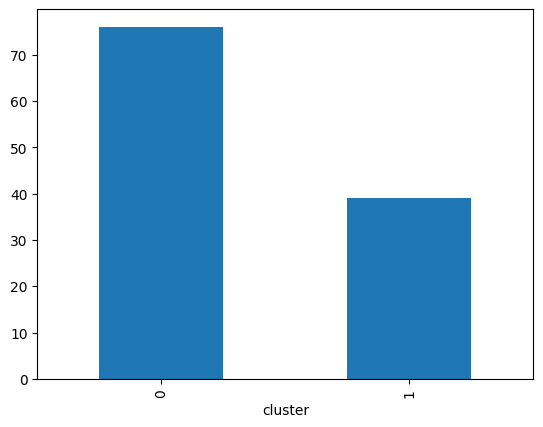

In [75]:
all_data.value_counts('cluster').plot(kind='bar')

In [82]:
with_denovo = pd.read_csv('/Users/kieran.lamb/Github/nipah_hackathon/datasets/nipah_metadata_with_denovo.csv')
with_denovo = with_denovo[['id', 'de_novo']]
with_denovo

,id,de_novo
0,azure-wolf-maple,no
1,calm-panda-fern,no
2,deep-heron-rose,no
3,ivory-orca-fern,no
4,azure-fox-flint,no
...,...,...
1196,quick-boar-fern,yes
1197,ivory-orca-ivy,yes
1198,crimson-crow-stone,yes
1199,lunar-quail-dust,yes


In [83]:
all_data = pd.merge(all_data, with_denovo, left_on='id', right_on='id')
all_data

,sequence,logits,embeddings,cluster,sequence_id,id,esmfold_structure_prediction_file,foldstring_1,proteinmpnn_score_1,proteinmpnn_seq_recovery_1,...,tm-scorepdb100_1,evalueafdb50_1,tm-scorecath50_1,rmsdcath50_1,aligned-lengthafdb50_1,cath_detail_1,evaluecath50_1,aligned-lengthcath50_1,bad_name,de_novo
0,SEVEKLIEKLEEVVSNDYSPQEAEKKTIDVIWEADRYIGETLQELL...,"[[-1.8920764923095703, -0.2780764400959015, -0...","[0.08740634471178055, -0.002664195606485009, -...",0,amber-tiger-dust_NipahG_BC2_binder_rank1,amber-tiger-dust,structures\01KBB3B9S3KH4N58Y5BVBF0S44.cif,HHHHHHH,1.3846,0.55359,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,amber-tiger-dust_NipahG_BC2_binder_rank1,yes
1,EEELIEEYEKREREEIRRLALEVADLLTSDPAAVGKAIKLATNAIA...,"[[-2.0214226245880127, -0.15610741078853607, -...","[0.10756595432758331, -0.028761660680174828, -...",0,azure-lion-willow_N237_batch_5_112_5,azure-lion-willow,structures\01KAEE9FYV5P7XNHJGVM085X7Q.cif,HHH,1.399,0.49772,...,0.67192,1.961,0.54654,2.96,74.0,Up Down Bundle,0.7765,74.0,azure-lion-willow_N237_batch_5_112_5,yes
2,EVQLVQSGAEVKKRGSSVKVSCKSSGGTFSNYAINWVRQAPGQGLE...,"[[-0.8582496047019958, -0.04903792962431908, -...","[-0.03265024349093437, -0.03014477714896202, -...",1,azure-wolf-maple_control-6CMI_3,azure-wolf-maple,structures\01KFJ2D1XA8TNNNAMEN3J97XP1.cif,EEEEEEEEE,1.503,0.5114,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,azure-wolf-maple_control-6CMI_3,no
3,IVLEPIYWNSSNPKFLPGQGLVLYPQIGDKLDIICPKVDVGQFEYY...,"[[-0.6130141615867615, -0.2109336107969284, -0...","[0.08268840610980988, -0.10497429966926575, -0...",1,bright-lion-oak_EPHRIN_B2_136_100_28,bright-lion-oak,structures\01KB8Y6C1Y4AVCY3WM3DV0FENW.cif,Eeeheehe,1.4847,0.47885,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bright-lion-oak_EPHRIN_B2_136_100_28,unknown
4,EEELIKEYEARRAAELAALEADIAALKALIAELGAARYADLIAFLD...,"[[-2.374033212661743, -0.20875999331474304, -0...","[-0.03400203213095665, 0.0199009720236063, -0....",0,bright-moth-stone_N1012,bright-moth-stone,structures\01KACGR2TX1HP45AQFD7EEBQAY.cif,HH,1.5119,0.38783,...,0.69852,2.614,0.60032,3.2,80.0,Up Down Bundle,2.187,74.0,bright-moth-stone_N1012,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,DLEELKKKAKEVLEKMEKEGELPDVGPSIEFTRKMRELEKKYGQEL...,"[[-4.354682922363281, -0.4237273931503296, -0....","[0.058432191610336304, -0.05198752507567406, -...",0,young-crane-granite_nipah_69-resample_6,young-crane-granite,structures\01KFNA9TT8FFTPZ9R1SRGPDHZW.cif,HHH,1.5321,0.53457,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,young-crane-granite_nipah_69-resample_6,yes
111,SELEVELRELGKEVVEQALAILEQIKAVAETLIEESKPNNGGQWWG...,"[[-2.7687273025512695, -0.19180439412593842, -...","[0.01715795323252678, -0.03865746036171913, -0...",0,young-quail-clay_design_10,young-quail-clay,structures\01KB8M59JXR9GWWWZS3C3SSA0D.cif,HHHHHH,1.4762,0.51819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,young-quail-clay_design_10,yes
112,EEELIKEYEEKEKEEIEKLLEEMLELLEELAKAAPKLSAEGVKYVQ...,"[[-1.90726900100708, -0.05148175731301308, -0....","[0.029197555035352707, 0.0003798294346779585, ...",0,young-ram-cloud_N237_batch_17_121_5,young-ram-cloud,structures\01KAV3TH6VP1GPGD34Q5GBYDZV.cif,HHHH,1.4192,0.51092,...,0.4261,1.533,0.63469,2.71,92.0,Up Down Bundle,2.608,93.0,young-ram-cloud_N237_batch_17_121_5,yes
113,MKKLSPAEAVLQEATTGDLSDPEAQIRTLAAMVLVTVEAIEKMKKA...,"[[-0.004058933816850185, -0.2896173298358917, ...","[0.06877387315034866, -0.05074091628193855, -0...",0,young-ram-rose_NipahG_BC2_binder_rank7,young-ram-rose,structures\01KBB3BRFMW5PE453CM8E7WV3D.cif,HHHHHH,1.3179,0.54752,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,young-ram-rose_NipahG_BC2_binder_rank7,yes


In [84]:
all_data[all_data.cluster == 0].value_counts('de_novo')

de_novo
yes        63
unknown     9
no          4
Name: count, dtype: int64

In [85]:
all_data[all_data.cluster == 1].value_counts('de_novo')

de_novo
no         35
unknown     4
Name: count, dtype: int64

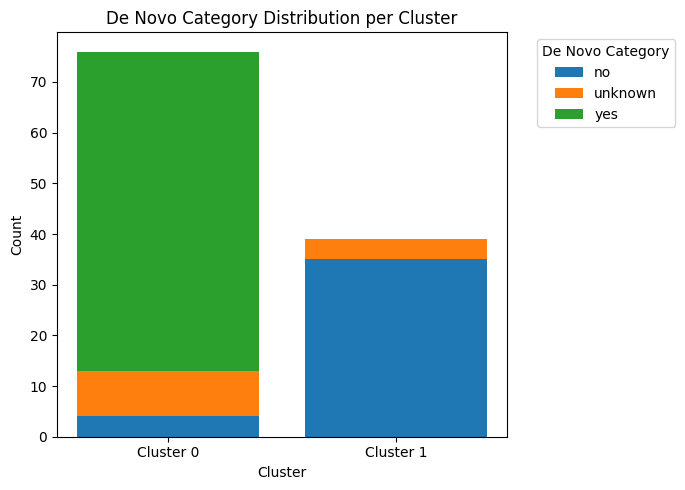

In [ ]:
import matplotlib.pyplot as plt

# Count de_novo categories per cluster
stacked = (
    all_data.groupby(['cluster', 'de_novo'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(7, 5))

bottom = None
colors = [f'C{i}' for i in range(len(stacked.columns))]

for col, color in zip(stacked.columns, colors):
    ax.bar(
        [f'Cluster {c}' for c in stacked.index],
        stacked[col],
        bottom=bottom,
        label=col,
        color=color
    )
    bottom = stacked[col].values if bottom is None else bottom + stacked[col].values

ax.set_xlabel('Cluster')
ax.set_ylabel('Count')
ax.set_title('De Novo Category Distribution per Cluster')
ax.legend(title='De Novo Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [88]:
all_data[(all_data.cluster == 0 ) & (all_data.de_novo != 'yes')]

,sequence,logits,embeddings,cluster,sequence_id,id,esmfold_structure_prediction_file,foldstring_1,proteinmpnn_score_1,proteinmpnn_seq_recovery_1,...,tm-scorepdb100_1,evalueafdb50_1,tm-scorecath50_1,rmsdcath50_1,aligned-lengthafdb50_1,cath_detail_1,evaluecath50_1,aligned-lengthcath50_1,bad_name,de_novo
13,VRIIVAPDTLTPSQVAELAYEELKALGFKRVLIVSVGDGRIWSGAN...,"[[-3.964571714401245, -0.13574635982513428, -0...","[0.08904320001602173, -0.037328753620386124, -...",0,"dark-shark-dust_mutant_('DB42W','TB67L')",dark-shark-dust,structures\01KB8X7719QC0EBYTP7361S0X8.cif,Heheheheh,1.1696,0.60267,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"dark-shark-dust_mutant_('DB42W','TB67L')",unknown
31,SGLDEYAELLAEGWKRKVDAGQDIKFTIKFQEFSPNLWGLESEEIY...,"[[-3.327075242996216, -0.5781429409980774, -0....","[0.06928739696741104, 0.0009241799707524478, -...",0,golden-swan-wave_2g9sol23,golden-swan-wave,structures\01KBCF2FCF14DVAXNB5ZAM2P8K.cif,Hehee,1.553,0.51794,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,golden-swan-wave_2g9sol23,no
32,SEIEELLKYIFDNKYKITNFYFRYLLDQIERGDFSVLDEFFEYLKE...,"[[-3.4450201988220215, -0.26319414377212524, -...","[0.20071271061897278, -0.05123629793524742, 0....",0,green-bear-cedar_l5iiin_1_run_0_overall_best|i...,green-bear-cedar,structures\01KB2GBVA7QP8J7W8V0RDFGC7A.cif,HHHHH,1.0119,0.7279,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,green-bear-cedar_l5iiin_1_run_0_overall_best|i...,unknown
39,GLVSVGDDSAVLSQNISSSTRSQLESILGQSLPSNITISQAYDLII...,"[[-1.0990900993347168, -0.39884069561958313, -...","[0.038004614412784576, 0.04215695708990097, 0....",0,lunar-bison-ice_latentx-Nipah_5,lunar-bison-ice,structures\01KB5CCTCGWWH4D10QZGEYVVZT.cif,HHHH,1.4743,0.42134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lunar-bison-ice_latentx-Nipah_5,unknown
43,SSETLEVPVGGEATFTVNNVNLEEGDYLVVTCKVAASTADVKPDFR...,"[[-1.5125608444213867, -0.2460084706544876, -0...","[0.045505642890930176, -0.07752521336078644, -...",0,lunar-panther-birch_task_29_NIPAH_2VSM_monomer...,lunar-panther-birch,structures\01KB9C35TWD6FMD0KS634SSXF9.cif,EEEEEEE,1.6207,0.46372,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lunar-panther-birch_task_29_NIPAH_2VSM_monomer...,unknown
48,SGLDEYAELLAEGWKRKVDAGQDIKFTIKFQEFSPNLWGLEPEEIY...,"[[-3.8401808738708496, -0.5452156662940979, -0...","[0.05932809039950371, 0.001597908791154623, -0...",0,noble-ox-cedar_2g9sol1,noble-ox-cedar,structures\01KBCF2GZ7DQ00HGBV3N1SCAY9.cif,Hehee,1.5263,0.50128,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,noble-ox-cedar_2g9sol1,no
64,SLVDEEIKWLKEDLETIKELIELVKNDESIPEEEREAYVAYLNALA...,"[[-2.415508508682251, -0.7853647470474243, -1....","[0.05394674465060234, -0.025224676355719566, -...",0,rapid-lynx-rose_1,rapid-lynx-rose,structures\01KBDJVJSVC729J6QN7R5PW4NN.cif,HHH,1.5267,0.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rapid-lynx-rose_1,unknown
66,MSPYKKAIEITKRLLELLLSNPELAKKNLGGIATLISLLALISALD...,"[[-0.0014354411978274584, -0.25663092732429504...","[0.057567257434129715, -0.005628247279673815, ...",0,rough-eagle-ash_antiHNV_C4,rough-eagle-ash,structures\01KBDZQ2GPZZHNNZ24FPERGKCJ.cif,HHHH,1.7827,0.36376,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rough-eagle-ash_antiHNV_C4,no
77,DAEKKKIMEEILKLFENSSLEKCKKMIDAIMNVLYFQSRISPETQE...,"[[-5.860416412353516, -0.8158937096595764, -0....","[0.11732128262519836, -0.046022478491067886, -...",0,silent-raven-frost_seq10,silent-raven-frost,structures\01KBAQWF8V6YDH8B5RH6F0VF5W.cif,HHHHH,1.1923,0.61145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,silent-raven-frost_seq10,unknown
88,AVTATISPDKTIKVGESTTITATFTPPLKEGDTLTIVAHNHGDLTA...,"[[-1.109177589416504, -0.16845554113388062, -0...","[0.04713154584169388, -0.07236035913228989, -0...",0,soft-lynx-oak_task_8_NIPAH_2VSM_monomer_385,soft-lynx-oak,structures\01KB9C2PH74KFMHNH2J888QWVH.cif,EEEEEEEE,1.3545,0.53522,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,soft-lynx-oak_task_8_NIPAH_2VSM_monomer_385,no


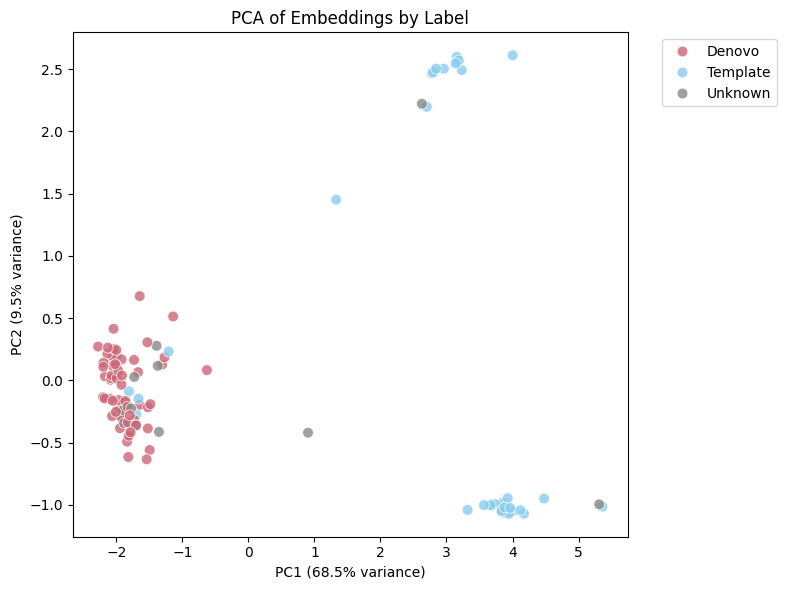

In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

map_labels = {
    'yes': 'Denovo',
    'no': 'Template',
    'unknown': 'Unknown'}

# Load your data
embeddings = embeddings_list   # shape: (n_samples, n_features)
labels = [map_labels.get(label, 'Unknown') for label in all_data.de_novo]  # your list of labels, length = n_samples

# Run PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Put everything into a dataframe for seaborn
df = pd.DataFrame({
    "PC1": embeddings_2d[:, 0],
    "PC2": embeddings_2d[:, 1],
    "label": labels
})

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x="PC1", y="PC2",
    hue="label", palette=['#CC6677','#88CCEE','#888888'],
    alpha=0.8, s=60
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA of Embeddings by Label")
plt.legend(title="" ,bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#88CCEE
#888888
#CC6677 